# V-JEPA + Segmentation on CAMUS Dataset
Replicating the US-JEPA paper pipeline: pre-trained V-JEPA encoder → frozen encoder → shallow decoder → cardiac segmentation

In [ ]:
!pip install -q kagglehub

import kagglehub

# Download latest version of the dataset
camus_path = kagglehub.dataset_download(
    "shoybhasan/camus-human-heart-data"
)

print("Dataset path:", camus_path)
print("Data source import complete.")

100%|██████████| 3.50G/3.50G [00:49<00:00, 76.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/shoybhasan/camus-human-heart-data/versions/3
Data source import complete.


In [ ]:
import os

for root, dirs, files in os.walk(camus_path):
    print(root)
    print("dirs:", dirs[:10])
    print("files:", files[:10])
    break

/root/.cache/kagglehub/datasets/shoybhasan/camus-human-heart-data/versions/3
dirs: []
files: ['download']


In [ ]:
import os

download_file = os.path.join(camus_path, "download")

print("Exists:", os.path.exists(download_file))
print("Size (GB):", os.path.getsize(download_file)/1024**3)

Exists: True
Size (GB): 3.571484385058284


In [ ]:
!file "/root/.cache/kagglehub/datasets/shoybhasan/camus-human-heart-data/versions/3/download"

/root/.cache/kagglehub/datasets/shoybhasan/camus-human-heart-data/versions/3/download: Zip archive data, at least v2.0 to extract, compression method=store


In [ ]:
import zipfile

download_file = os.path.join(camus_path, "download")

print(zipfile.is_zipfile(download_file))

True


In [ ]:
import os, glob, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import nibabel as nib
from PIL import Image
import matplotlib.pyplot as plt
import timm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print(torch.cuda.get_device_name(0), '|', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), 'GB')

Device: cuda
Tesla T4 | 15.6 GB


In [ ]:
import zipfile
import os

download_file = os.path.join(camus_path, "download")
extract_dir = "/content/camus"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(download_file, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted!")

Extracted!


In [ ]:
import os

for root, dirs, files in os.walk("/content/camus"):
    print(root)
    print("dirs:", dirs[:10])
    print("files:", files[:10])
    break

/content/camus
dirs: ['database_nifti']
files: []


In [ ]:
import glob

patient_dirs = glob.glob(
    "/content/camus/**/patient*",
    recursive=True
)

print("Found", len(patient_dirs), "patients")
print(patient_dirs[:5])

Found 6500 patients
['/content/camus/database_nifti/patient0495', '/content/camus/database_nifti/patient0427', '/content/camus/database_nifti/patient0319', '/content/camus/database_nifti/patient0272', '/content/camus/database_nifti/patient0288']


In [ ]:
DATA_ROOT = "/content/camus/**/patient*"
IMG_SIZE  = 224
BATCH     = 2
LR        = 1e-3
EPOCHS    = 50
LAMBDA_LL = 0.25
NUM_CLASSES = 4  # background, LV endo, LV epi, LA wall

patient_dirs = sorted(glob.glob(os.path.join(DATA_ROOT, 'patient*')))
print(f'Found {len(patient_dirs)} patients')

Found 6000 patients


In [ ]:
import os

# Explore one patient to understand file structure
if patient_dirs:
    # The original `patient_dirs` list contains file paths instead of directory paths.
    # To explore the file structure of a patient, we need the path to the patient's directory.
    # We extract the parent directory from the first file path in `patient_dirs`.
    p_file_path = patient_dirs[0]
    p_patient_dir = os.path.dirname(p_file_path)
    for f in sorted(os.listdir(p_patient_dir)):
        print(f)

Info_2CH.cfg
Info_4CH.cfg
MANDATORY_CITATION.md
patient0001_2CH_ED.nii.gz
patient0001_2CH_ED_gt.nii.gz
patient0001_2CH_ES.nii.gz
patient0001_2CH_ES_gt.nii.gz
patient0001_2CH_half_sequence.nii.gz
patient0001_2CH_half_sequence_gt.nii.gz
patient0001_4CH_ED.nii.gz
patient0001_4CH_ED_gt.nii.gz
patient0001_4CH_ES.nii.gz
patient0001_4CH_ES_gt.nii.gz
patient0001_4CH_half_sequence.nii.gz
patient0001_4CH_half_sequence_gt.nii.gz


In [ ]:
import os
import re
import glob # Import glob for glob.glob

def find_image_gt_pairs(data_root_glob_pattern):
    pairs = []
    views = ['2CH', '4CH']
    phases = ['ED', 'ES']

    # 1. Expand the glob pattern to find all actual patient directories
    # e.g., '/content/camus/**/patient*' should expand to directories like
    # '/content/camus/database_nifti/patient0001', '/content/camus/database_nifti/patient0002', etc.
    all_patient_dirs = sorted(glob.glob(data_root_glob_pattern, recursive=True))

    for pdir in all_patient_dirs:
        # Ensure it's an actual directory before proceeding
        if not os.path.isdir(pdir):
            continue

        pid = os.path.basename(pdir) # Extract 'patient0001' from '/path/to/patient0001'

        for view in views:
            for phase in phases:
                # Construct paths to the NIfTI files inside the patient directory
                img_path = os.path.join(pdir, f'{pid}_{view}_{phase}.nii.gz')
                gt_path = os.path.join(pdir, f'{pid}_{view}_{phase}_gt.nii.gz')

                if os.path.exists(img_path) and os.path.exists(gt_path):
                    pairs.append((img_path, gt_path))

    return pairs

# DATA_ROOT is defined in a previous cell as "/content/camus/**/patient*"
all_pairs = find_image_gt_pairs(DATA_ROOT)
print(f'Total image-GT pairs: {len(all_pairs)}')
if all_pairs:
    print('Example:', all_pairs[0])

Total image-GT pairs: 2000
Example: ('/content/camus/database_nifti/patient0001/patient0001_2CH_ED.nii.gz', '/content/camus/database_nifti/patient0001/patient0001_2CH_ED_gt.nii.gz')


In [ ]:
def load_nifti_as_array(path):
    nii = nib.load(path)
    return nii.get_fdata()

Image shape: (549, 389) | GT shape: (549, 389)
GT unique values: [0. 1. 2. 3.]


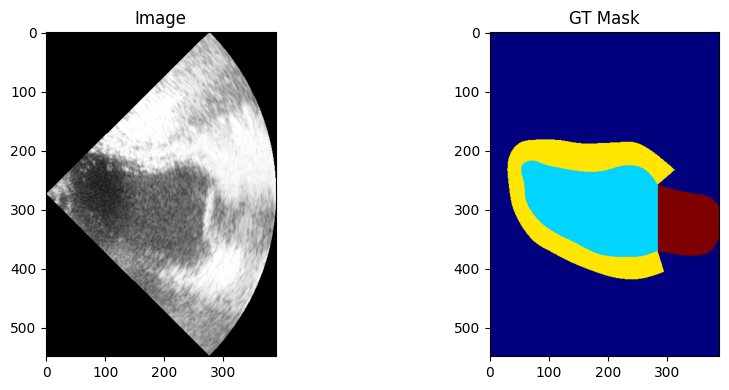

In [ ]:
# Verify shapes and label values
if all_pairs:
    img, gt = all_pairs[0]
    arr_img = load_nifti_as_array(img)
    arr_gt  = load_nifti_as_array(gt)
    print('Image shape:', arr_img.shape, '| GT shape:', arr_gt.shape)
    print('GT unique values:', np.unique(arr_gt))
    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1); plt.imshow(arr_img[...,0] if arr_img.ndim==3 else arr_img, cmap='gray'); plt.title('Image')
    plt.subplot(1,2,2); plt.imshow(arr_gt[...,0] if arr_gt.ndim==3 else arr_gt, cmap='jet');  plt.title('GT Mask')
    plt.tight_layout(); plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)
print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)}')

Train: 1600 | Val: 400


In [ ]:
img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

def nifti_to_2d(path):
    arr = load_nifti_as_array(path)
    if arr.ndim == 3:
        arr = arr[..., arr.shape[-1]//2]
    arr = arr.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255
    return Image.fromarray(arr.astype(np.uint8))

def nifti_gt_to_2d(path):
    arr = load_nifti_as_array(path)
    if arr.ndim == 3:
        arr = arr[..., arr.shape[-1]//2]
    return arr.astype(np.int64)

class CAMUSDataset(Dataset):
    def __init__(self, pairs, img_transform):
        self.pairs = pairs
        self.img_transform = img_transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, gt_path = self.pairs[idx]
        img_pil = nifti_to_2d(img_path)
        img_rgb = img_pil.convert('RGB')
        img_t   = self.img_transform(img_rgb)

        gt_arr  = nifti_gt_to_2d(gt_path)
        gt_pil  = Image.fromarray(gt_arr.astype(np.uint8))
        gt_res  = gt_pil.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        gt_t    = torch.from_numpy(np.array(gt_res)).long()

        return img_t, gt_t

train_ds = CAMUSDataset(train_pairs, img_tf)
val_ds   = CAMUSDataset(val_pairs,   img_tf)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print('Loaders ready')

Loaders ready


In [ ]:
# Verify one batch
imgs, gts = next(iter(train_dl))
print('Image batch:', imgs.shape, '| GT batch:', gts.shape)
print('GT unique labels in batch:', gts.unique().tolist())

Image batch: torch.Size([2, 3, 224, 224]) | GT batch: torch.Size([2, 224, 224])
GT unique labels in batch: [0, 1, 2, 3]


In [ ]:
# ViT-B encoder from timm (lighter than ViT-L, fits on T4)
# To use ViT-L: change to 'vit_large_patch16_224'
encoder = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=0,
    global_pool=''
).to(DEVICE)

# Freeze all encoder weights (as in the paper)
for p in encoder.parameters():
    p.requires_grad = False

encoder.eval()
print('Encoder frozen. Params:', sum(p.numel() for p in encoder.parameters()), '| Trainable:', sum(p.numel() for p in encoder.parameters() if p.requires_grad))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Encoder frozen. Params: 85798656 | Trainable: 0


In [ ]:
# Verify encoder output shape
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    feat  = encoder(dummy)
    print('Encoder output shape:', feat.shape)
    # Expected: [1, 197, 768] for ViT-B (196 patches + 1 CLS token)

Encoder output shape: torch.Size([1, 197, 768])


In [ ]:
EMBED_DIM  = encoder(torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(DEVICE)).shape[-1]
PATCH_SIZE = 16
NUM_PATCHES_SIDE = IMG_SIZE // PATCH_SIZE  # 14

# Shallow decoder: 2 × Transpose Convolution layers (as in paper)
decoder = nn.Sequential(
    nn.ConvTranspose2d(EMBED_DIM, 256, kernel_size=4, stride=2, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(128, NUM_CLASSES, kernel_size=1)
).to(DEVICE)

print('Decoder trainable params:', sum(p.numel() for p in decoder.parameters()))

Decoder trainable params: 3671684


In [ ]:
# Test full forward pass
with torch.no_grad():
    dummy   = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    feat    = encoder(dummy)          # [1, 197, 768]
    patch_t = feat[:, 1:, :]         # drop CLS token -> [1, 196, 768]
    B, N, C = patch_t.shape
    H = W = int(N**0.5)
    patch_2d = patch_t.permute(0,2,1).reshape(B, C, H, W)  # [1, 768, 14, 14]
    logits   = decoder(patch_2d)     # [1, 4, 56, 56]
    logits   = F.interpolate(logits, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    print('Output logits shape:', logits.shape)  # [1, 4, 224, 224]

Output logits shape: torch.Size([1, 4, 224, 224])


In [ ]:
def forward_pass(imgs):
    with torch.no_grad():
        feat = encoder(imgs)
    patch_t  = feat[:, 1:, :]
    B, N, C  = patch_t.shape
    H = W    = int(N**0.5)
    patch_2d = patch_t.permute(0,2,1).reshape(B, C, H, W)
    logits   = decoder(patch_2d)
    logits   = F.interpolate(logits, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    return logits

In [ ]:
# Local Loss: penalizes spatial inconsistency between adjacent patch predictions
def local_loss(logits):
    probs = torch.softmax(logits, dim=1)
    diff_h = (probs[:, :, 1:, :] - probs[:, :, :-1, :]).pow(2).mean()
    diff_w = (probs[:, :, :, 1:] - probs[:, :, :, :-1]).pow(2).mean()
    return diff_h + diff_w

ce_loss  = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(decoder.parameters(), lr=LR, weight_decay=1e-4)

def cosine_lr(step, total_steps, base_lr, min_lr=0.0):
    progress = step / max(total_steps, 1)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * progress))

total_steps = EPOCHS * len(train_dl)

In [ ]:
def dice_score(preds, targets, num_classes=NUM_CLASSES, eps=1e-6):
    dices = []
    pred_mask = preds.argmax(dim=1)
    for c in range(1, num_classes):
        p = (pred_mask == c).float()
        t = (targets   == c).float()
        inter = (p * t).sum()
        dices.append(((2 * inter + eps) / (p.sum() + t.sum() + eps)).item())
    return np.mean(dices)

def jaccard_score(preds, targets, num_classes=NUM_CLASSES, eps=1e-6):
    jis = []
    pred_mask = preds.argmax(dim=1)
    for c in range(1, num_classes):
        p = (pred_mask == c).float()
        t = (targets   == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        jis.append(((inter + eps) / (union + eps)).item())
    return np.mean(jis)

In [ ]:
train_losses, val_dices, val_jis = [], [], []
global_step = 0

for epoch in range(EPOCHS):
    decoder.train()
    epoch_loss = 0.0

    for imgs, gts in train_dl:
        imgs, gts = imgs.to(DEVICE), gts.to(DEVICE)

        for g in optimizer.param_groups:
            g['lr'] = cosine_lr(global_step, total_steps, LR)

        logits = forward_pass(imgs)
        loss   = ce_loss(logits, gts) + LAMBDA_LL * local_loss(logits)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        global_step += 1

    avg_loss = epoch_loss / len(train_dl)
    train_losses.append(avg_loss)

    decoder.eval()
    dsc_list, ji_list = [], []
    with torch.no_grad():
        for imgs, gts in val_dl:
            imgs, gts = imgs.to(DEVICE), gts.to(DEVICE)
            logits    = forward_pass(imgs)
            dsc_list.append(dice_score(logits, gts))
            ji_list.append(jaccard_score(logits, gts))

    mean_dsc = np.mean(dsc_list)
    mean_ji  = np.mean(ji_list)
    val_dices.append(mean_dsc)
    val_jis.append(mean_ji)

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | DSC: {mean_dsc:.4f} | JI: {mean_ji:.4f}')

Epoch   1/50 | Loss: 0.2064 | DSC: 0.8149 | JI: 0.6955
Epoch   5/50 | Loss: 0.1186 | DSC: 0.8499 | JI: 0.7441
Epoch  10/50 | Loss: 0.0885 | DSC: 0.8549 | JI: 0.7528
Epoch  15/50 | Loss: 0.0627 | DSC: 0.8575 | JI: 0.7558
Epoch  20/50 | Loss: 0.0428 | DSC: 0.8581 | JI: 0.7562
Epoch  25/50 | Loss: 0.0295 | DSC: 0.8605 | JI: 0.7601
Epoch  30/50 | Loss: 0.0207 | DSC: 0.8607 | JI: 0.7605
Epoch  35/50 | Loss: 0.0153 | DSC: 0.8615 | JI: 0.7618
Epoch  40/50 | Loss: 0.0120 | DSC: 0.8620 | JI: 0.7624
Epoch  45/50 | Loss: 0.0105 | DSC: 0.8618 | JI: 0.7621
Epoch  50/50 | Loss: 0.0100 | DSC: 0.8617 | JI: 0.7620


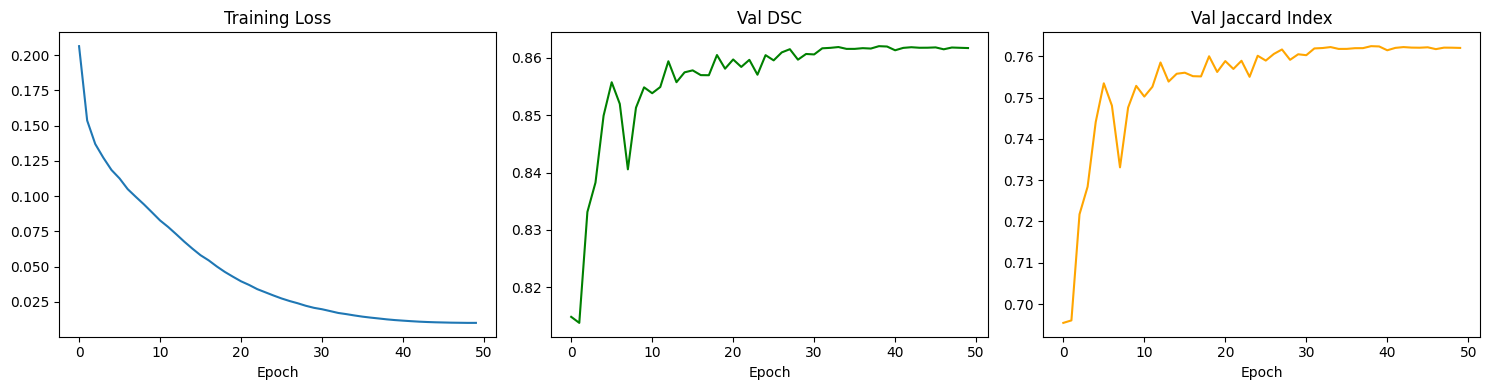

Best DSC: 0.8620 | Best JI: 0.7624


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(train_losses); axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(val_dices, color='green'); axes[1].set_title('Val DSC'); axes[1].set_xlabel('Epoch')
axes[2].plot(val_jis, color='orange'); axes[2].set_title('Val Jaccard Index'); axes[2].set_xlabel('Epoch')
plt.tight_layout(); plt.show()
print(f'Best DSC: {max(val_dices):.4f} | Best JI: {max(val_jis):.4f}')

/tmp/ipykernel_7410/3347407454.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('jet', NUM_CLASSES)


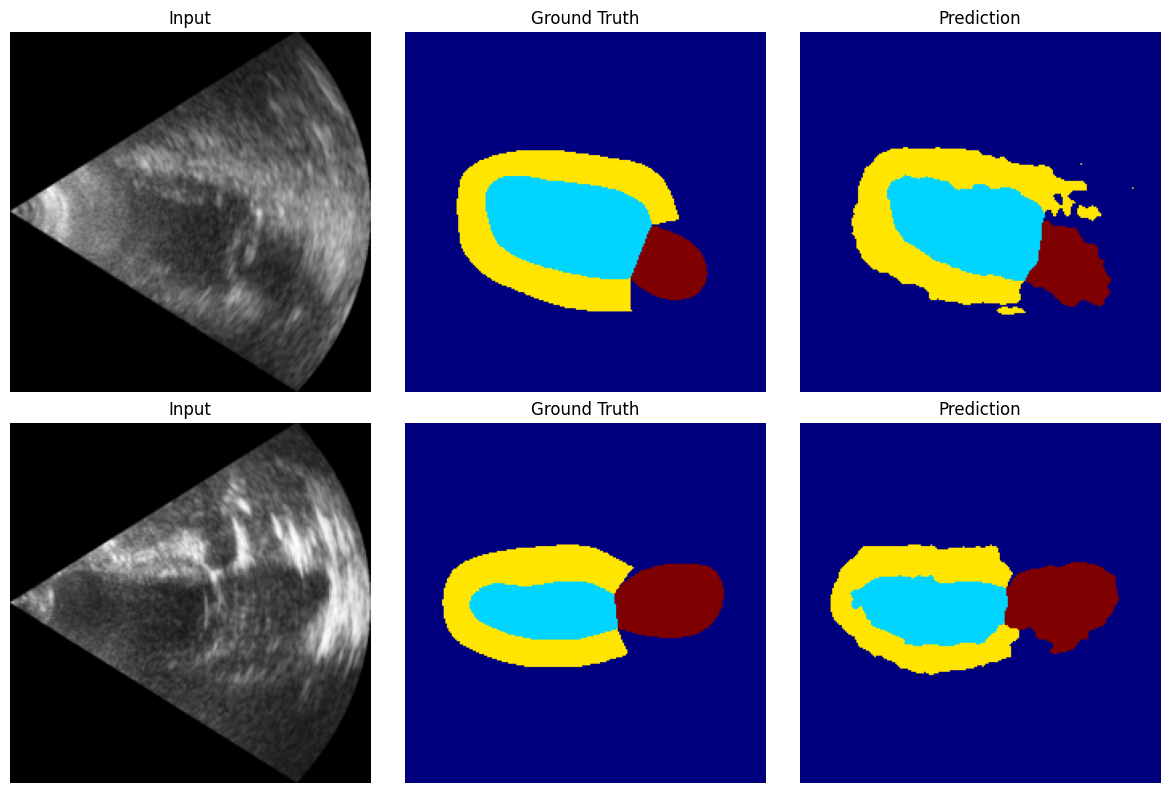

In [ ]:
# Visualize predictions on validation samples
decoder.eval()
imgs_vis, gts_vis = next(iter(val_dl))
imgs_vis, gts_vis = imgs_vis.to(DEVICE), gts_vis.to(DEVICE)

with torch.no_grad():
    logits_vis = forward_pass(imgs_vis)
    pred_vis   = logits_vis.argmax(dim=1)

n = min(4, imgs_vis.shape[0])
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
cmap = plt.cm.get_cmap('jet', NUM_CLASSES)

for i in range(n):
    img_np = imgs_vis[i].cpu().permute(1,2,0).numpy()
    img_np = (img_np * 0.5 + 0.5).clip(0,1)
    img_gray = img_np.mean(axis=2)

    axes[i,0].imshow(img_gray, cmap='gray'); axes[i,0].set_title('Input'); axes[i,0].axis('off')
    axes[i,1].imshow(gts_vis[i].cpu(), cmap=cmap, vmin=0, vmax=NUM_CLASSES-1); axes[i,1].set_title('Ground Truth'); axes[i,1].axis('off')
    axes[i,2].imshow(pred_vis[i].cpu(), cmap=cmap, vmin=0, vmax=NUM_CLASSES-1); axes[i,2].set_title('Prediction'); axes[i,2].axis('off')

plt.tight_layout(); plt.show()

In [ ]:
# Precision (PPV) and Recall for final evaluation
def precision_recall(preds, targets, num_classes=NUM_CLASSES, eps=1e-6):
    pred_mask = preds.argmax(dim=1)
    ppv_list, rec_list = [], []
    for c in range(1, num_classes):
        p = (pred_mask == c).float()
        t = (targets   == c).float()
        tp = (p * t).sum()
        ppv_list.append(((tp + eps) / (p.sum() + eps)).item())
        rec_list.append(((tp + eps) / (t.sum() + eps)).item())
    return np.mean(ppv_list), np.mean(rec_list)

decoder.eval()
all_dsc, all_ji, all_ppv, all_rec = [], [], [], []
with torch.no_grad():
    for imgs, gts in val_dl:
        imgs, gts = imgs.to(DEVICE), gts.to(DEVICE)
        logits    = forward_pass(imgs)
        all_dsc.append(dice_score(logits, gts))
        all_ji.append(jaccard_score(logits, gts))
        ppv, rec = precision_recall(logits, gts)
        all_ppv.append(ppv); all_rec.append(rec)

print(f'  DSC (Dice):      {np.mean(all_dsc):.4f} ± {np.std(all_dsc):.4f}')
print(f'  JI  (Jaccard):   {np.mean(all_ji):.4f} ± {np.std(all_ji):.4f}')
print(f'  PPV (Precision): {np.mean(all_ppv):.4f} ± {np.std(all_ppv):.4f}')
print(f'  Recall:          {np.mean(all_rec):.4f} ± {np.std(all_rec):.4f}')

  DSC (Dice):      0.8617 ± 0.0371
  JI  (Jaccard):   0.7620 ± 0.0531
  PPV (Precision): 0.8663 ± 0.0416
  Recall:          0.8625 ± 0.0430


In [ ]:
# Save decoder weights
torch.save(decoder.state_dict(), 'vjepa_decoder_camus.pth')
print('Saved: vjepa_decoder_camus.pth')

Saved: vjepa_decoder_camus.pth


## Ablation: Partial Unfreezing
Unfreeze last N transformer blocks of the encoder and fine-tune end-to-end.  
This replicates the paper's comparison of 12 vs 16 frozen blocks.

In [ ]:
def unfreeze_last_n_blocks(model, n):
    for p in model.parameters():
        p.requires_grad = False
    blocks = list(model.blocks)
    for block in blocks[-n:]:
        for p in block.parameters():
            p.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Unfroze last {n} blocks | Trainable encoder params: {trainable:,}')

# Example: unfreeze last 2 blocks
unfreeze_last_n_blocks(encoder, n=2)

optimizer2 = torch.optim.AdamW(
    list(filter(lambda p: p.requires_grad, encoder.parameters())) + list(decoder.parameters()),
    lr=1e-4, weight_decay=1e-4
)
print('Ablation optimizer ready')

Unfroze last 2 blocks | Trainable encoder params: 14,175,744
Ablation optimizer ready


In [ ]:
ABLATION_EPOCHS = 20
abl_losses, abl_dices = [], []
global_step2 = 0
abl_total    = ABLATION_EPOCHS * len(train_dl)

for epoch in range(ABLATION_EPOCHS):
    encoder.train(); decoder.train()
    epoch_loss = 0.0

    for imgs, gts in train_dl:
        imgs, gts = imgs.to(DEVICE), gts.to(DEVICE)

        for g in optimizer2.param_groups:
            g['lr'] = cosine_lr(global_step2, abl_total, 1e-4)

        feat     = encoder(imgs)
        patch_t  = feat[:, 1:, :]
        B, N, C  = patch_t.shape
        H = W    = int(N**0.5)
        patch_2d = patch_t.permute(0,2,1).reshape(B, C, H, W)
        logits   = decoder(patch_2d)
        logits   = F.interpolate(logits, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)

        loss     = ce_loss(logits, gts) + LAMBDA_LL * local_loss(logits)
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        epoch_loss += loss.item()
        global_step2 += 1

    encoder.eval(); decoder.eval()
    dsc_list = []
    with torch.no_grad():
        for imgs, gts in val_dl:
            imgs, gts = imgs.to(DEVICE), gts.to(DEVICE)
            feat     = encoder(imgs)
            patch_t  = feat[:, 1:, :]
            B, N, C  = patch_t.shape
            H = W    = int(N**0.5)
            patch_2d = patch_t.permute(0,2,1).reshape(B, C, H, W)
            logits   = decoder(patch_2d)
            logits   = F.interpolate(logits, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
            dsc_list.append(dice_score(logits, gts))

    abl_losses.append(epoch_loss / len(train_dl))
    abl_dices.append(np.mean(dsc_list))

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f'Ablation Epoch {epoch+1:2d}/{ABLATION_EPOCHS} | Loss: {abl_losses[-1]:.4f} | DSC: {abl_dices[-1]:.4f}')

print(f'Ablation Best DSC: {max(abl_dices):.4f}')

Ablation Epoch  1/20 | Loss: 0.0541 | DSC: 0.8544
Ablation Epoch  5/20 | Loss: 0.0262 | DSC: 0.8626
Ablation Epoch 10/20 | Loss: 0.0170 | DSC: 0.8660
Ablation Epoch 15/20 | Loss: 0.0109 | DSC: 0.8682
Ablation Epoch 20/20 | Loss: 0.0094 | DSC: 0.8683
Ablation Best DSC: 0.8684


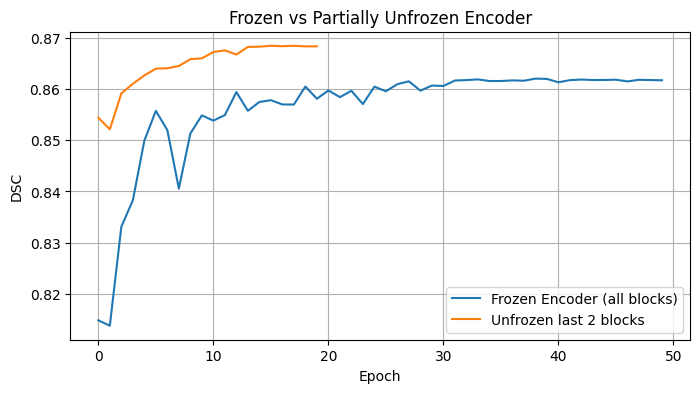

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(val_dices, label='Frozen Encoder (all blocks)')
plt.plot(abl_dices, label='Unfrozen last 2 blocks')
plt.xlabel('Epoch'); plt.ylabel('DSC'); plt.title('Frozen vs Partially Unfrozen Encoder')
plt.legend(); plt.grid(True); plt.show()

In [ ]:
#Save full checkpoint
import torch, os

SAVE_PATH = 'vjepa_camus_checkpoint.pt'

torch.save({
    'encoder_arch':   'vit_base_patch16_224',   # to recreate encoder
    'embed_dim':       EMBED_DIM,
    'num_classes':     NUM_CLASSES,
    'img_size':        IMG_SIZE,
    'decoder_state':   decoder.state_dict(),
    'best_val_dsc':    max(val_dices),
    'train_losses':    train_losses,
    'val_dices':       val_dices,
    'val_jis':         val_jis,
}, SAVE_PATH)

print(f'Full checkpoint saved → {SAVE_PATH}  ({os.path.getsize(SAVE_PATH)/1e6:.1f} MB)')

Full checkpoint saved → vjepa_camus_checkpoint.pt  (14.7 MB)
